Analizando paciente Sano: Z001.txt
--------------------------------------------------


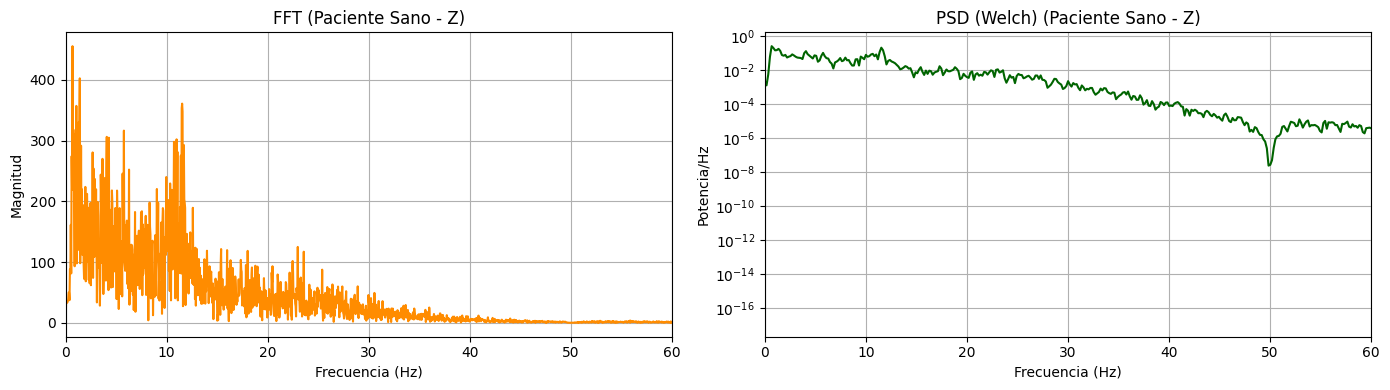

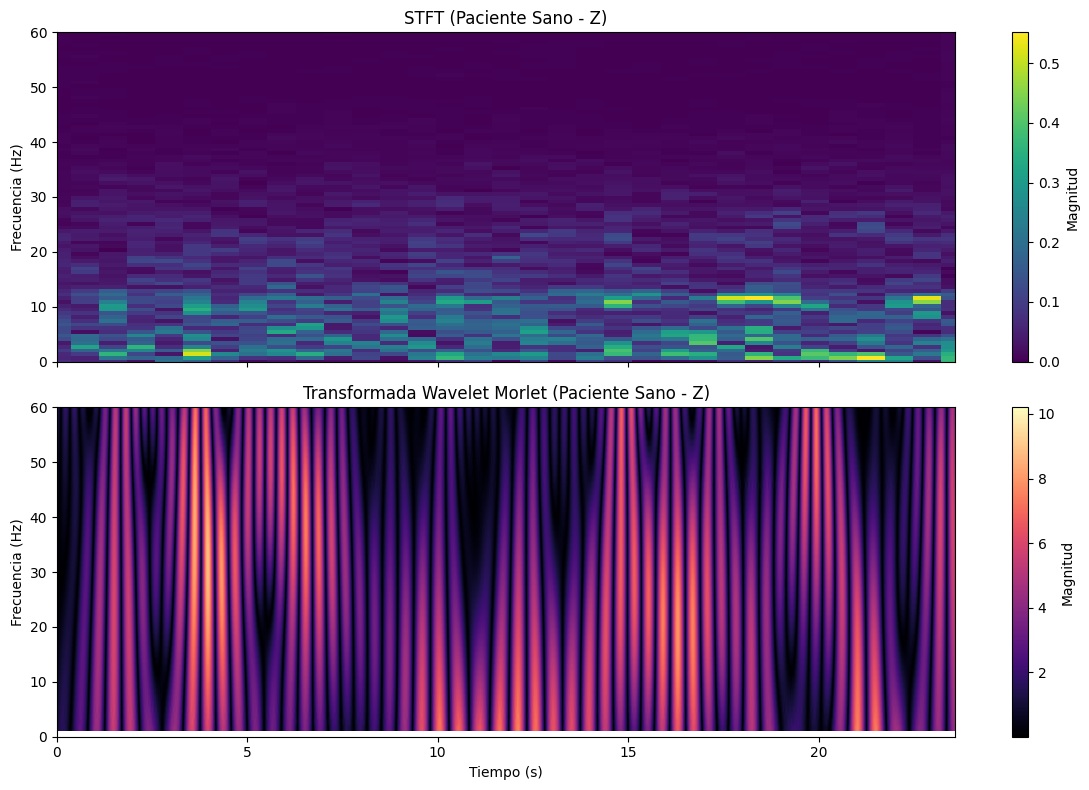


Analizando paciente Ictal: S001.txt
--------------------------------------------------


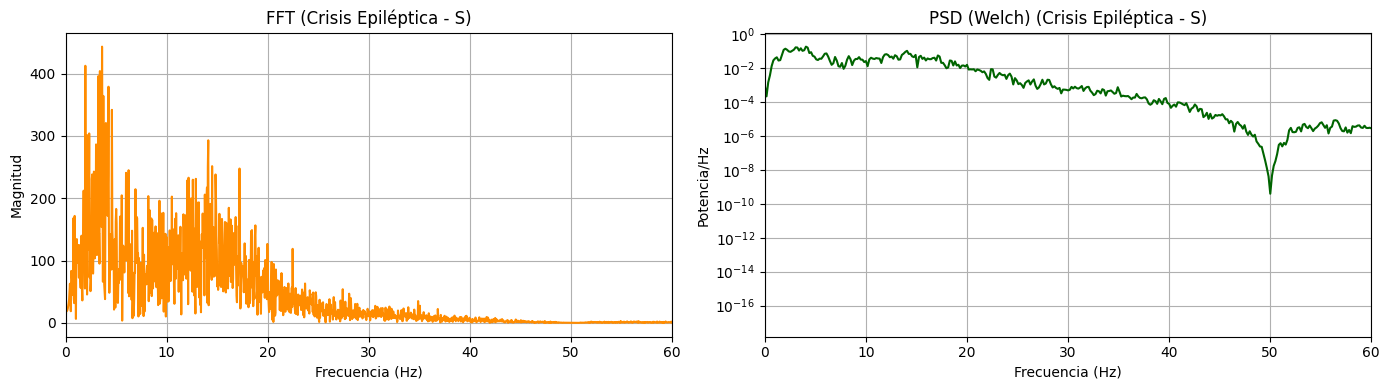

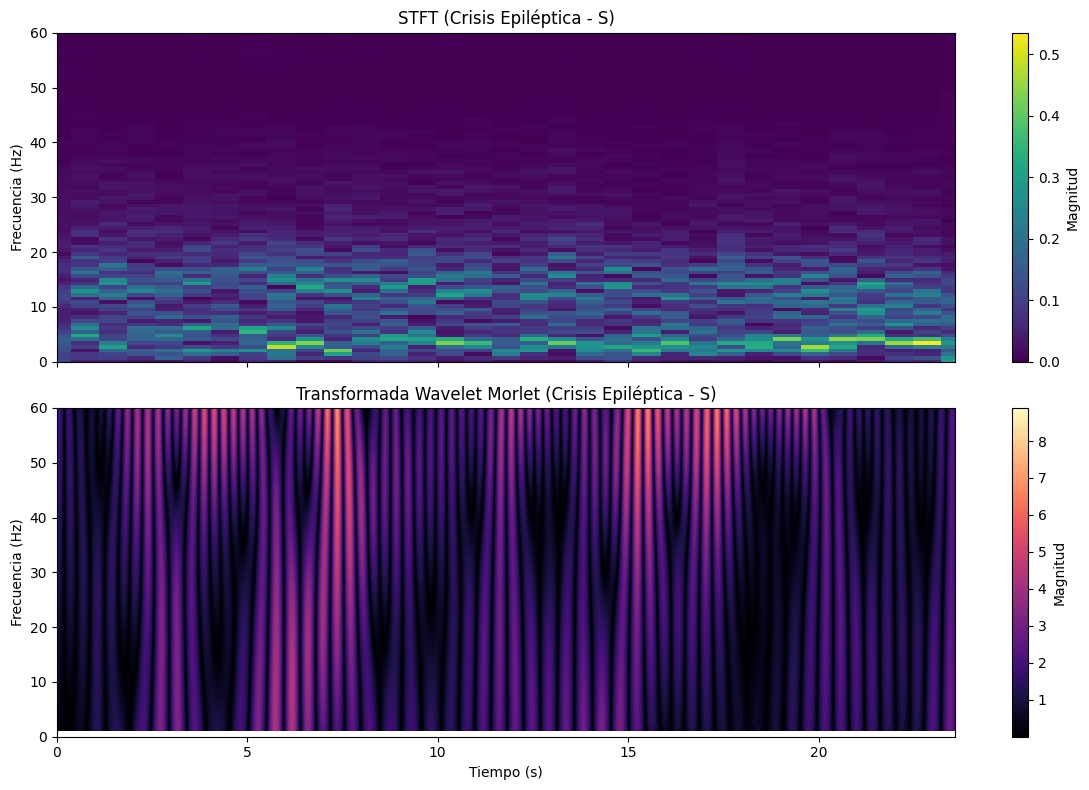

In [10]:
%matplotlib inline
import sys
import pandas as pd

# 1. Le decimos a Python que busque en la carpeta principal del proyecto
sys.path.append('../') 

# 2. Ahora sí podemos importar desde src
from src.caracteristicas import plot_espectro_frecuencias, plot_tiempo_frecuencia

# 3. Cargar los datos ya preprocesados
df_eeg = pd.read_pickle('../data/processed/dataset_preprocesado.pkl')

# 4. Seleccionar una muestra Sana (Z) y una muestra Ictal/Epiléptica (S)
sano = df_eeg[df_eeg['carpeta_original'] == 'Z'].iloc[0]
ictal = df_eeg[df_eeg['carpeta_original'] == 'S'].iloc[0]

print(f"Analizando paciente Sano: {sano['archivo']}")
print("-" * 50)
plot_espectro_frecuencias(sano['senal_limpia'], titulo_extra="(Paciente Sano - Z)")
plot_tiempo_frecuencia(sano['senal_limpia'], titulo_extra="(Paciente Sano - Z)")

print(f"\nAnalizando paciente Ictal: {ictal['archivo']}")
print("-" * 50)
plot_espectro_frecuencias(ictal['senal_limpia'], titulo_extra="(Crisis Epiléptica - S)")
plot_tiempo_frecuencia(ictal['senal_limpia'], titulo_extra="(Crisis Epiléptica - S)")

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.caracteristicas import matriz_features, conjuntos_de_features

df_seg = pd.read_pickle('../data/processed/dataset_segmentado.pkl')
feats = matriz_features(df_seg['senal'].values)

meta = df_seg[['archivo', 'carpeta_original', 'clase', 'ventana', 'etiqueta']].reset_index(drop=True)
df_feat = pd.concat([meta, feats], axis=1)
df_feat.to_csv('../data/processed/features.csv', index=False)

print(df_feat.shape)
print('NaN en features:', int(feats.isna().sum().sum()))
{k: len(v) for k, v in conjuntos_de_features(feats.columns).items()}

(5000, 58)
NaN en features: 0


{'A_estadisticas': 10,
 'B_espectral_clasico': 23,
 'C_tiempo_frecuencia': 40,
 'D_todo': 53}

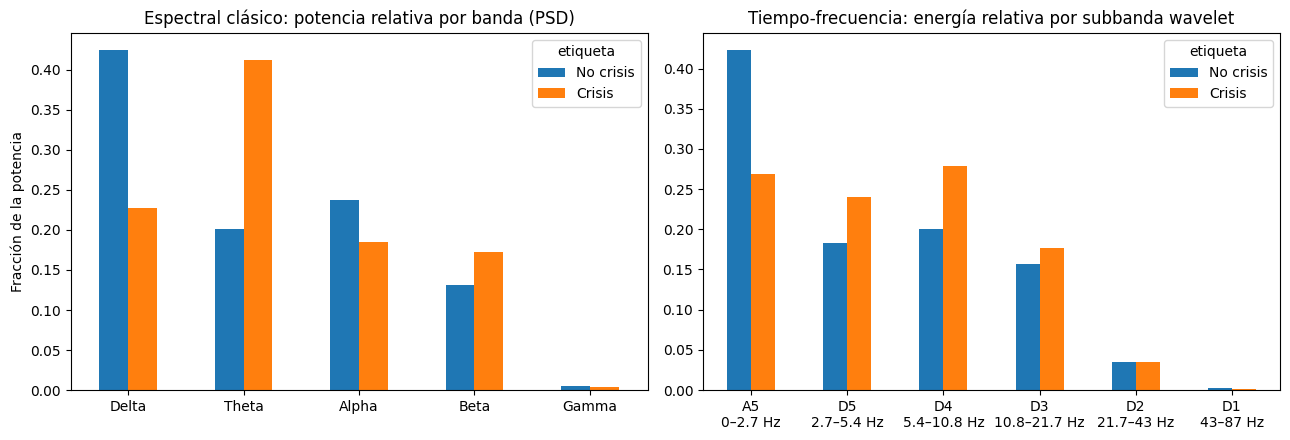

In [12]:
df_feat = pd.read_csv('../data/processed/features.csv')

bandas = ['Delta', 'Theta', 'Alpha', 'Beta', 'Gamma']
rel_psd = df_feat.groupby('etiqueta')[[f'psd_rel_{b}' for b in bandas]].mean()
rel_psd.columns = bandas

rango_hz = {'A5': '0–2.7', 'D5': '2.7–5.4', 'D4': '5.4–10.8', 'D3': '10.8–21.7', 'D2': '21.7–43', 'D1': '43–87'}
cols_w = [c for c in df_feat.columns if c.startswith('wav_rel_')]
rel_wav = df_feat.groupby('etiqueta')[cols_w].mean()
rel_wav.columns = [f"{c.split('_')[-1]}\n{rango_hz[c.split('_')[-1]]} Hz" for c in cols_w]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
rel_psd.rename(index={0: 'No crisis', 1: 'Crisis'}).T.plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title('Espectral clásico: potencia relativa por banda (PSD)'); axes[0].set_ylabel('Fracción de la potencia')
rel_wav.rename(index={0: 'No crisis', 1: 'Crisis'}).T.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('Tiempo-frecuencia: energía relativa por subbanda wavelet')
plt.tight_layout()
plt.savefig('../figuras/bandas_y_wavelet.png', dpi=200, bbox_inches='tight')
plt.show()

In [13]:
from sklearn.feature_selection import f_classif

X = df_feat[feats.columns]
y = df_feat['etiqueta'].values

F, p = f_classif(X, y)
ranking = pd.DataFrame({'feature': X.columns, 'F_anova': F, 'p_valor': p}) \
            .sort_values('F_anova', ascending=False).reset_index(drop=True)
ranking['familia'] = ranking['feature'].str.split('_').str[0].map(
    {'est': 'estadística', 'psd': 'espectral clásica', 'wav': 'tiempo-frecuencia', 'stft': 'tiempo-frecuencia'})
display(ranking.head(15))

,feature,F_anova,p_valor,familia
0,est_std,9594.470228,0.000000e+00,estadística
1,est_rms,9591.436970,0.000000e+00,estadística
2,est_rango,8085.956169,0.000000e+00,estadística
3,est_long_linea,6555.304407,0.000000e+00,estadística
4,est_hjorth_actividad,4493.303076,0.000000e+00,estadística
5,wav_E_D4,3369.103084,0.000000e+00,tiempo-frecuencia
6,wav_E_D5,3163.783908,0.000000e+00,tiempo-frecuencia
7,psd_abs_Theta,2805.803380,0.000000e+00,espectral clásica
8,psd_abs_Alpha,2547.670669,0.000000e+00,espectral clásica
9,wav_E_D3,2175.626428,0.000000e+00,tiempo-frecuencia


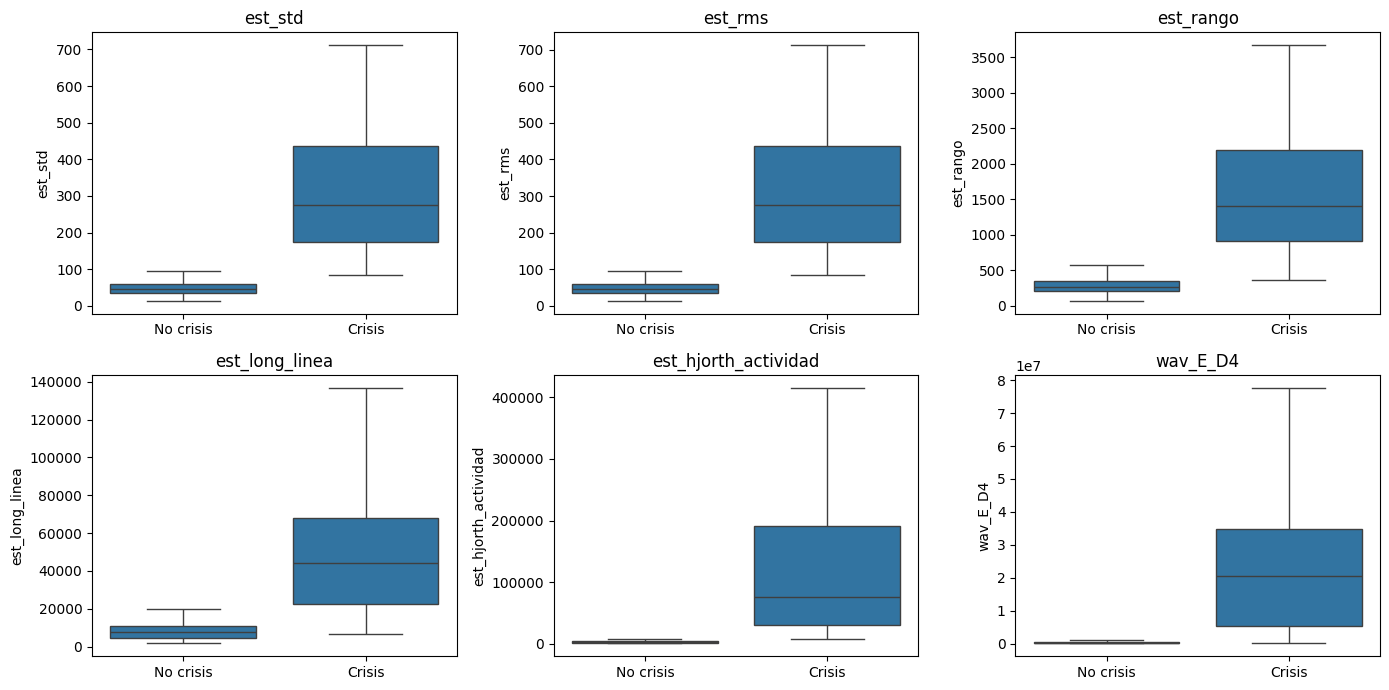

In [14]:
top6 = ranking['feature'].head(6).tolist()
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, f in zip(axes.ravel(), top6):
    sns.boxplot(data=df_feat, x='etiqueta', y=f, ax=ax, showfliers=False)
    ax.set_xticks([0, 1]); ax.set_xticklabels(['No crisis', 'Crisis']); ax.set_xlabel(''); ax.set_title(f)
plt.tight_layout(); plt.show()

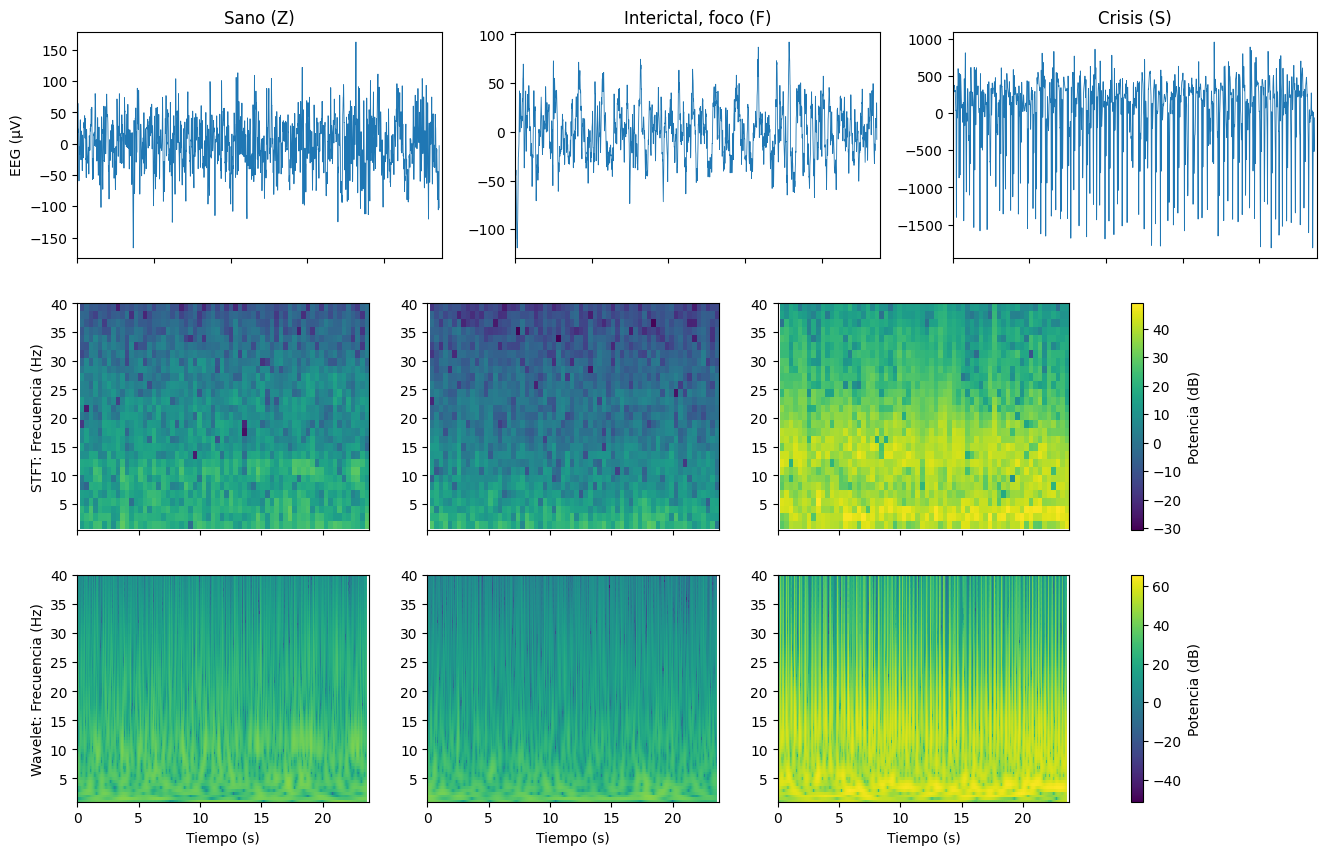

In [ ]:
import sys
sys.path.append('../')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.dataset import cargar_dataset_completo
from src.preprocesamiento import filtrar_senal
from src.caracteristicas import calcular_stft, calcular_wavelet, calcular_psd, FS

os.makedirs('../figuras', exist_ok=True)

df_raw = cargar_dataset_completo('../data/raw/')
clases = {'Sano (Z)': 'Z', 'Interictal, foco (F)': 'F', 'Crisis (S)': 'S'}
senales = {n: filtrar_senal(df_raw[df_raw.carpeta_original == c].iloc[0]['senal']) for n, c in clases.items()}
t = np.arange(len(next(iter(senales.values())))) / FS

esp_reg = {}
for n, x in senales.items():
    f, tt, P = calcular_stft(x)
    P, tt = P[:, 1:-1], tt[1:-1]            
    k = f >= 0.5                             
    f, P = f[k], P[k]
    fw, Pw = calcular_wavelet(x)
    esp_reg[n] = (10*np.log10(P + 1e-12), f, tt, 10*np.log10(Pw + 1e-12), fw)
vs = (min(v[0][v[1] <= 40].min() for v in esp_reg.values()),        # CORRECCIÓN 3: escala de color solo con 0.5-40 Hz
      max(v[0][v[1] <= 40].max() for v in esp_reg.values()))
vw = (min(v[3].min() for v in esp_reg.values()), max(v[3].max() for v in esp_reg.values()))

fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharex=True)
for j, (n, x) in enumerate(senales.items()):
    S, f, tt, W, fw = esp_reg[n]
    o = np.argsort(fw)
    axes[0, j].plot(t, x, lw=0.6); axes[0, j].set_title(n)
    im1 = axes[1, j].pcolormesh(tt, f, S, shading='auto', vmin=vs[0], vmax=vs[1]); axes[1, j].set_ylim(0.5, 40)
    im2 = axes[2, j].pcolormesh(t, fw[o], W[o], shading='auto', vmin=vw[0], vmax=vw[1]); axes[2, j].set_ylim(1, 40)
    axes[2, j].set_xlabel('Tiempo (s)')
axes[0, 0].set_ylabel('EEG (µV)'); axes[1, 0].set_ylabel('STFT: Frecuencia (Hz)'); axes[2, 0].set_ylabel('Wavelet: Frecuencia (Hz)')
fig.colorbar(im1, ax=axes[1, :], label='Potencia (dB)'); fig.colorbar(im2, ax=axes[2, :], label='Potencia (dB)')
plt.savefig('../figuras/tres_clases_2d.png', dpi=200, bbox_inches='tight')
plt.show()

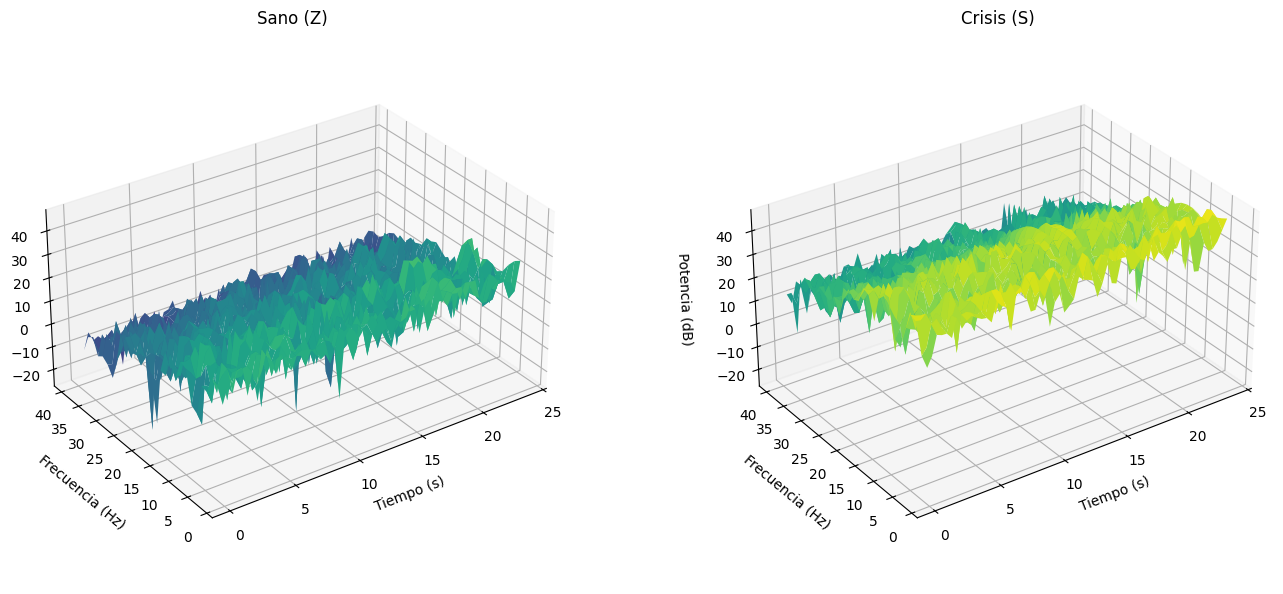

In [21]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

nombres = ['Sano (Z)', 'Crisis (S)']
zmin = min(esp_reg[n][0][esp_reg[n][1] <= 40].min() for n in nombres)   # escala solo con 0.5-40 Hz
zmax = max(esp_reg[n][0][esp_reg[n][1] <= 40].max() for n in nombres)

fig = plt.figure(figsize=(15, 6))
posiciones = [[0.10, 0.02, 0.39, 0.92], [0.57, 0.02, 0.39, 0.92]]   # margen izquierdo para el eje z
for i, n in enumerate(nombres):
    S, f, tt, _, _ = esp_reg[n]
    m = f <= 40
    T, Fq = np.meshgrid(tt, f[m])
    ax = fig.add_axes(posiciones[i], projection='3d')
    ax.plot_surface(T, Fq, S[m], cmap='viridis', linewidth=0, vmin=zmin, vmax=zmax)
    ax.set_zlim(zmin, zmax); ax.view_init(elev=30, azim=-125)
    ax.set_box_aspect((1.4, 1, 0.7), zoom=0.95)
    ax.set_xlabel('Tiempo (s)', labelpad=8); ax.set_ylabel('Frecuencia (Hz)', labelpad=8)
    ax.set_zlabel('Potencia (dB)', labelpad=8)
    ax.set_title(n)
plt.savefig('../figuras/superficie_3d.png', dpi=200)      # sin bbox_inches='tight' para no recortar el eje z
plt.show()

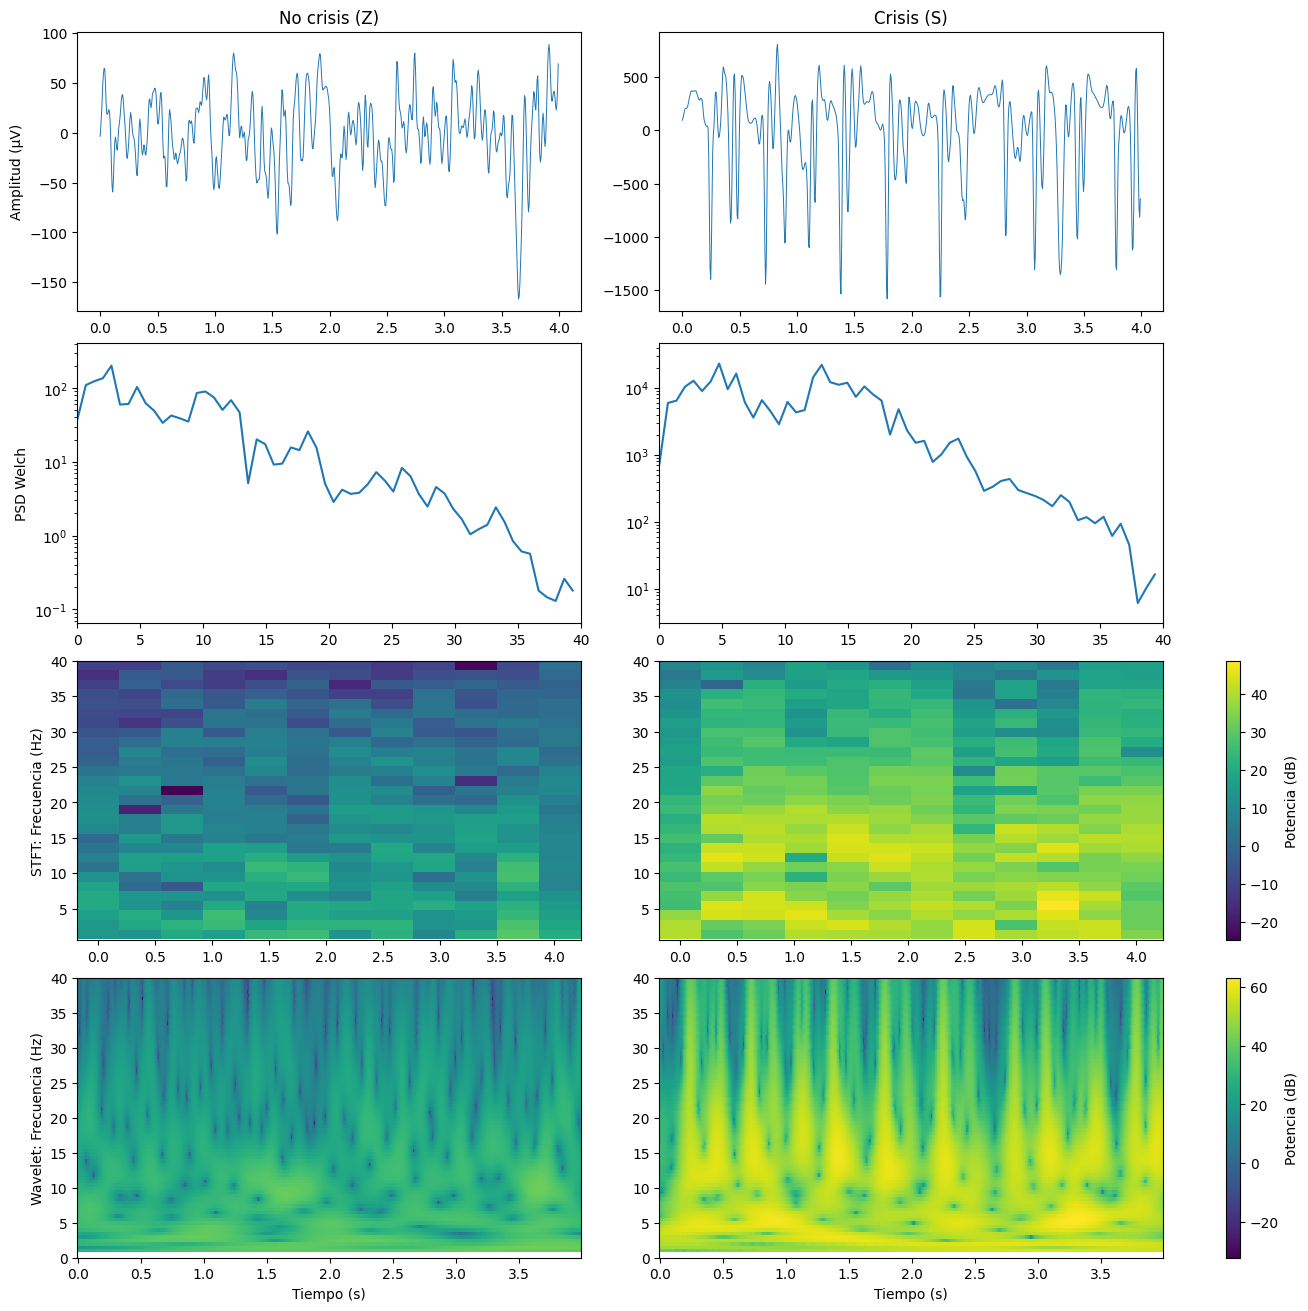

In [22]:
df_seg = pd.read_pickle('../data/processed/dataset_segmentado.pkl')
ejemplos = {
    'No crisis (Z)': df_seg[df_seg.carpeta_original == 'Z'].iloc[0]['senal'],
    'Crisis (S)':    df_seg[df_seg.carpeta_original == 'S'].iloc[0]['senal'],
}

esp_v = {}
for nombre, x in ejemplos.items():
    fs_, ts_, P = calcular_stft(x)
    k = fs_ >= 0.5                           # quita la fila de 0 Hz
    fs_, P = fs_[k], P[k]
    fw, Pw = calcular_wavelet(x)
    esp_v[nombre] = (10*np.log10(P + 1e-12), fs_, ts_, 10*np.log10(Pw + 1e-12), fw)
vmin_s = min(v[0][v[1] <= 40].min() for v in esp_v.values()); vmax_s = max(v[0][v[1] <= 40].max() for v in esp_v.values())
vmin_w = min(v[3].min() for v in esp_v.values()); vmax_w = max(v[3].max() for v in esp_v.values())

fig, axes = plt.subplots(4, 2, figsize=(13, 13), constrained_layout=True)
for j, (nombre, x) in enumerate(ejemplos.items()):
    tt = np.arange(len(x)) / FS
    S, fs_, ts_, W, fw = esp_v[nombre]
    axes[0, j].plot(tt, x, lw=0.7); axes[0, j].set_title(nombre)
    f, p = calcular_psd(x)
    m = f <= 40
    axes[1, j].semilogy(f[m], p[m])                                   # solo 0-40 Hz
    axes[1, j].set_xlim(0, 40); axes[1, j].set_ylim(p[m].min()*0.5, p[m].max()*2)
    im1 = axes[2, j].pcolormesh(ts_, fs_, S, shading='auto', vmin=vmin_s, vmax=vmax_s); axes[2, j].set_ylim(0.5, 40)
    o = np.argsort(fw)
    im2 = axes[3, j].pcolormesh(tt, fw[o], W[o], shading='auto', vmin=vmin_w, vmax=vmax_w); axes[3, j].set_ylim(0, 40)
    axes[3, j].set_xlabel('Tiempo (s)')
for i, lab in enumerate(['Amplitud (µV)', 'PSD Welch', 'STFT: Frecuencia (Hz)', 'Wavelet: Frecuencia (Hz)']):
    axes[i, 0].set_ylabel(lab)
fig.colorbar(im1, ax=axes[2, :], label='Potencia (dB)')
fig.colorbar(im2, ax=axes[3, :], label='Potencia (dB)')
plt.savefig('../figuras/metodos_lado_a_lado.png', dpi=200, bbox_inches='tight')
plt.show()

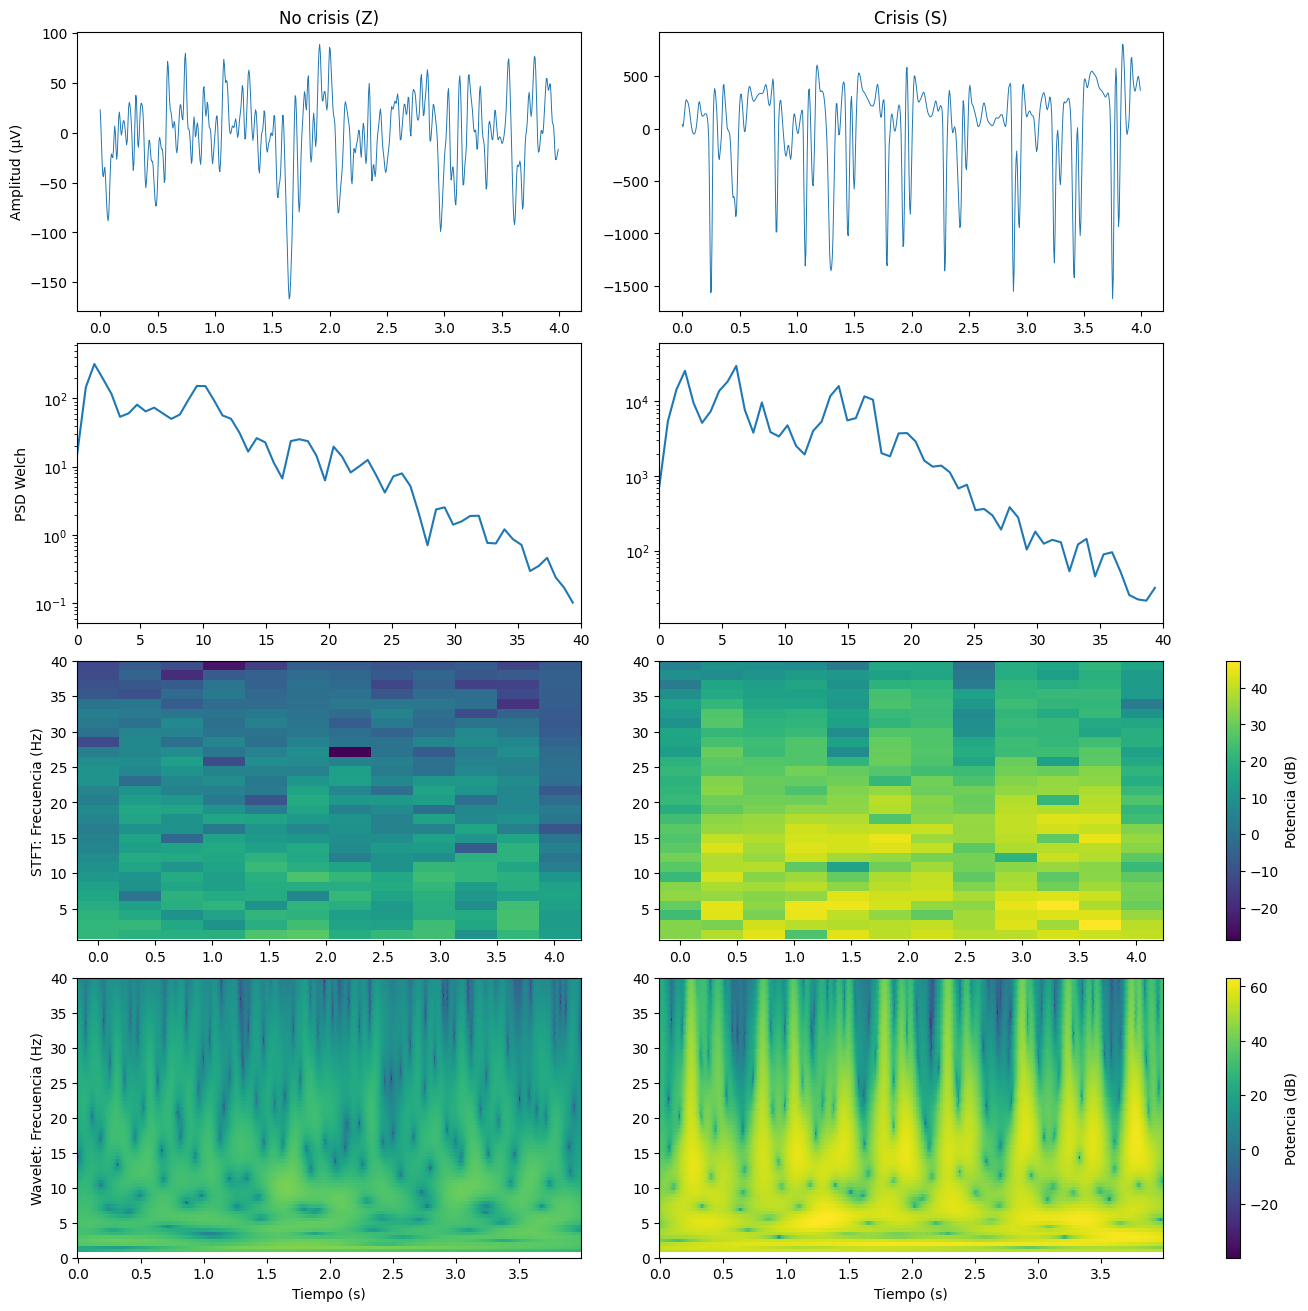

In [23]:
df_seg = pd.read_pickle('../data/processed/dataset_segmentado.pkl')
ejemplos = {
    'No crisis (Z)': df_seg[df_seg.carpeta_original == 'Z'].iloc[1]['senal'],
    'Crisis (S)':    df_seg[df_seg.carpeta_original == 'S'].iloc[1]['senal'],
}

esp_v = {}
for nombre, x in ejemplos.items():
    fs_, ts_, P = calcular_stft(x)
    k = fs_ >= 0.5                           # quita la fila de 0 Hz
    fs_, P = fs_[k], P[k]
    fw, Pw = calcular_wavelet(x)
    esp_v[nombre] = (10*np.log10(P + 1e-12), fs_, ts_, 10*np.log10(Pw + 1e-12), fw)
vmin_s = min(v[0][v[1] <= 40].min() for v in esp_v.values()); vmax_s = max(v[0][v[1] <= 40].max() for v in esp_v.values())
vmin_w = min(v[3].min() for v in esp_v.values()); vmax_w = max(v[3].max() for v in esp_v.values())

fig, axes = plt.subplots(4, 2, figsize=(13, 13), constrained_layout=True)
for j, (nombre, x) in enumerate(ejemplos.items()):
    tt = np.arange(len(x)) / FS
    S, fs_, ts_, W, fw = esp_v[nombre]
    axes[0, j].plot(tt, x, lw=0.7); axes[0, j].set_title(nombre)
    f, p = calcular_psd(x)
    m = f <= 40
    axes[1, j].semilogy(f[m], p[m])                                   # solo 0-40 Hz
    axes[1, j].set_xlim(0, 40); axes[1, j].set_ylim(p[m].min()*0.5, p[m].max()*2)
    im1 = axes[2, j].pcolormesh(ts_, fs_, S, shading='auto', vmin=vmin_s, vmax=vmax_s); axes[2, j].set_ylim(0.5, 40)
    o = np.argsort(fw)
    im2 = axes[3, j].pcolormesh(tt, fw[o], W[o], shading='auto', vmin=vmin_w, vmax=vmax_w); axes[3, j].set_ylim(0, 40)
    axes[3, j].set_xlabel('Tiempo (s)')
for i, lab in enumerate(['Amplitud (µV)', 'PSD Welch', 'STFT: Frecuencia (Hz)', 'Wavelet: Frecuencia (Hz)']):
    axes[i, 0].set_ylabel(lab)
fig.colorbar(im1, ax=axes[2, :], label='Potencia (dB)')
fig.colorbar(im2, ax=axes[3, :], label='Potencia (dB)')
plt.savefig('../figuras/metodos_lado_a_lado2.png', dpi=200, bbox_inches='tight')
plt.show()